In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier


In [21]:
%pip install matplotlib seaborn

  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (9.0 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl (7.8 MB)
Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl (249 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 2.9 MB/s  0:00:00 eta 0:00:01
Using cached importlib_resources-6.5.2-py3-none-any.whl (37 kB)
Using cached kiwisolver-1.4.7-cp39-cp39-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-11.3.0-cp39-cp39-macosx_11_0_arm64.whl (4.7 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [seaborn

In [32]:
import pandas as pd

df = pd.read_csv("../DATASETS/bp_dataset/bp_dataset.csv")
print(df.head())
df.shape
df.columns
df.isnull().sum()

   Num.  subject_ID Sex(M/F)  Age(year)  Height(cm)  Weight(kg)  \
0     1           2   Female         45         152          63   
1     2           3   Female         50         157          50   
2     3           6   Female         47         150          47   
3     4           8     Male         45         172          65   
4     5           9   Female         46         155          65   

   Systolic Blood Pressure(mmHg)  Diastolic Blood Pressure(mmHg)  \
0                            161                              89   
1                            160                              93   
2                            101                              71   
3                            136                              93   
4                            123                              73   

   Heart Rate(b/m)  BMI(kg/m^2)          Hypertension Diabetes  \
0               97        27.27  Stage 2 hypertension      NaN   
1               76        20.28  Stage 2 hypertension   

Num.                                0
subject_ID                          0
Sex(M/F)                            0
Age(year)                           0
Height(cm)                          0
Weight(kg)                          0
Systolic Blood Pressure(mmHg)       0
Diastolic Blood Pressure(mmHg)      0
Heart Rate(b/m)                     0
BMI(kg/m^2)                         0
Hypertension                        0
Diabetes                          181
cerebral infarction               199
cerebrovascular disease           194
dtype: int64

In [33]:
df = df.drop(columns=[
    'Num.', 
    'subject_ID', 
    'Diabetes', 
    'cerebral infarction', 
    'cerebrovascular disease'
])


In [34]:
df['Sex(M/F)'] = df['Sex(M/F)'].map({'Male': 1, 'Female': 0})


In [35]:
df['Hypertension'].value_counts()



Hypertension
Prehypertension         85
Normal                  80
Stage 1 hypertension    34
Stage 2 hypertension    20
Name: count, dtype: int64

In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['Hypertension_encoded'] = le.fit_transform(df['Hypertension'])


In [37]:
X = df.drop(columns=['Hypertension', 'Hypertension_encoded'])
y = df['Hypertension_encoded']


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [39]:
X_train.shape

(175, 8)

In [40]:
y.value_counts()


Hypertension_encoded
1    85
0    80
2    34
3    20
Name: count, dtype: int64

In [41]:
le.classes_

array(['Normal', 'Prehypertension', 'Stage 1 hypertension',
       'Stage 2 hypertension'], dtype=object)

In [42]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

model_lr = LogisticRegression(max_iter=1000, multi_class='auto')
model_lr.fit(X_train_scaled, y_train)
y_pred_lr = model_lr.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))




Accuracy: 0.9318181818181818

Classification Report:
                       precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        16
     Prehypertension       0.89      1.00      0.94        17
Stage 1 hypertension       0.83      0.71      0.77         7
Stage 2 hypertension       1.00      0.75      0.86         4

            accuracy                           0.93        44
           macro avg       0.93      0.87      0.89        44
        weighted avg       0.93      0.93      0.93        44


Confusion Matrix:
 [[16  0  0  0]
 [ 0 17  0  0]
 [ 0  2  5  0]
 [ 0  0  1  3]]


/Users/abrarfarhann/CODING/main project sub /.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [43]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy_score(y_test, y_pred_lr)]
})

results


,Model,Accuracy
0,Logistic Regression,0.931818


In [44]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))


Random Forest Accuracy: 0.9545454545454546

Classification Report:
                       precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        16
     Prehypertension       0.94      1.00      0.97        17
Stage 1 hypertension       0.86      0.86      0.86         7
Stage 2 hypertension       1.00      0.75      0.86         4

            accuracy                           0.95        44
           macro avg       0.95      0.90      0.92        44
        weighted avg       0.96      0.95      0.95        44


Confusion Matrix:
 [[16  0  0  0]
 [ 0 17  0  0]
 [ 0  1  6  0]
 [ 0  0  1  3]]


In [45]:
xgb_model_reg = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,     # L1 regularization
    reg_lambda=2,    # L2 regularization
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)


In [46]:
from xgboost import XGBClassifier
xgb_model_reg = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,     # L1 regularization
    reg_lambda=2,    # L2 regularization
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model_reg.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model_reg.predict(X_test_scaled)

print("XGBoost Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb, target_names=le.classes_))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


XGBoost Accuracy: 1.0

Classification Report:
                       precision    recall  f1-score   support

              Normal       1.00      1.00      1.00        16
     Prehypertension       1.00      1.00      1.00        17
Stage 1 hypertension       1.00      1.00      1.00         7
Stage 2 hypertension       1.00      1.00      1.00         4

            accuracy                           1.00        44
           macro avg       1.00      1.00      1.00        44
        weighted avg       1.00      1.00      1.00        44


Confusion Matrix:
 [[16  0  0  0]
 [ 0 17  0  0]
 [ 0  0  7  0]
 [ 0  0  0  4]]


In [47]:


# Binary label (example: hypertension)
y_binary = (df['Systolic Blood Pressure(mmHg)'] >= 140).astype(int)


In [48]:
X_noleak = X.drop(columns=[
    'Systolic Blood Pressure(mmHg)',
    'Diastolic Blood Pressure(mmHg)'
])

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_noleak, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train2_scaled = scaler.fit_transform(X_train2)
X_test2_scaled = scaler.transform(X_test2)

xgb_model2 = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model2.fit(X_train2_scaled, y_train2)
y_pred2 = xgb_model2.predict(X_test2_scaled)

print("New XGB Accuracy:", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2, target_names=le.classes_))


New XGB Accuracy: 0.38636363636363635
                      precision    recall  f1-score   support

              Normal       0.41      0.44      0.42        16
     Prehypertension       0.35      0.41      0.38        17
Stage 1 hypertension       0.50      0.43      0.46         7
Stage 2 hypertension       0.00      0.00      0.00         4

            accuracy                           0.39        44
           macro avg       0.32      0.32      0.32        44
        weighted avg       0.36      0.39      0.37        44



In [49]:
xgb_model_reg = XGBClassifier(
    n_estimators=100,
    max_depth=2,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=1,     # L1 regularization
    reg_lambda=2,    # L2 regularization
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)


In [50]:
# Remove leaking features
X_noleak = X.drop(columns=[
    'Systolic Blood Pressure(mmHg)',
    'Diastolic Blood Pressure(mmHg)'
])

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_noleak, y, test_size=0.2, random_state=42, stratify=y
)

scaler2 = StandardScaler()
X_train2_scaled = scaler2.fit_transform(X_train2)
X_test2_scaled = scaler2.transform(X_test2)

xgb_model2 = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='multi:softmax',
    num_class=4,
    eval_metric='mlogloss',
    random_state=42
)

xgb_model2.fit(X_train2_scaled, y_train2)

y_pred2 = xgb_model2.predict(X_test2_scaled)

print("Accuracy (without SBP & DBP):", accuracy_score(y_test2, y_pred2))
print(classification_report(y_test2, y_pred2, target_names=le.classes_))


Accuracy (without SBP & DBP): 0.38636363636363635
                      precision    recall  f1-score   support

              Normal       0.41      0.44      0.42        16
     Prehypertension       0.35      0.41      0.38        17
Stage 1 hypertension       0.50      0.43      0.46         7
Stage 2 hypertension       0.00      0.00      0.00         4

            accuracy                           0.39        44
           macro avg       0.32      0.32      0.32        44
        weighted avg       0.36      0.39      0.37        44



In [51]:
y_binary = y.copy()

# Stage1 (2) and Stage2 (3) → 1 (Hypertensive)
# Normal (0) and Prehypertension (1) → 0 (Non-hypertensive)
y_binary = y_binary.apply(lambda x: 1 if x in [2,3] else 0)

y_binary.value_counts()


Hypertension_encoded
0    165
1     54
Name: count, dtype: int64

In [52]:
# Features

# Binary label (example: hypertension)
y_binary = (df['Systolic Blood Pressure(mmHg)'] >= 140).astype(int)


In [53]:
X_noleak = X.drop(columns=[
    'Systolic Blood Pressure(mmHg)',
    'Diastolic Blood Pressure(mmHg)'
])

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_noleak, y_binary, test_size=0.2, random_state=42, stratify=y_binary
)

scaler = StandardScaler()
X_train_b_scaled = scaler.fit_transform(X_train_b)
X_test_b_scaled = scaler.transform(X_test_b)

from xgboost import XGBClassifier

xgb_bin = XGBClassifier(
    n_estimators=150,
    max_depth=3,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)

xgb_bin.fit(X_train_b_scaled, y_train_b)
y_pred_b = xgb_bin.predict(X_test_b_scaled)

from sklearn.metrics import accuracy_score, classification_report
print("Binary Accuracy:", accuracy_score(y_test_b, y_pred_b))
print(classification_report(y_test_b, y_pred_b))


Binary Accuracy: 0.8409090909090909
              precision    recall  f1-score   support

           0       0.91      0.88      0.89        33
           1       0.67      0.73      0.70        11

    accuracy                           0.84        44
   macro avg       0.79      0.80      0.79        44
weighted avg       0.85      0.84      0.84        44



In [54]:
y_prob = xgb_bin.predict_proba(X_test_b_scaled)
risk_score = y_prob[:,1] * 100

for i in range(10):
    print(f"True: {y_test_b.iloc[i]}, Pred: {y_pred_b[i]}, Risk: {risk_score[i]:.2f}%")


True: 0, Pred: 0, Risk: 23.97%
True: 0, Pred: 0, Risk: 12.82%
True: 1, Pred: 1, Risk: 89.44%
True: 0, Pred: 0, Risk: 7.43%
True: 0, Pred: 0, Risk: 4.78%
True: 0, Pred: 0, Risk: 4.24%
True: 0, Pred: 1, Risk: 75.84%
True: 0, Pred: 0, Risk: 0.57%
True: 1, Pred: 1, Risk: 79.85%
True: 0, Pred: 0, Risk: 1.52%


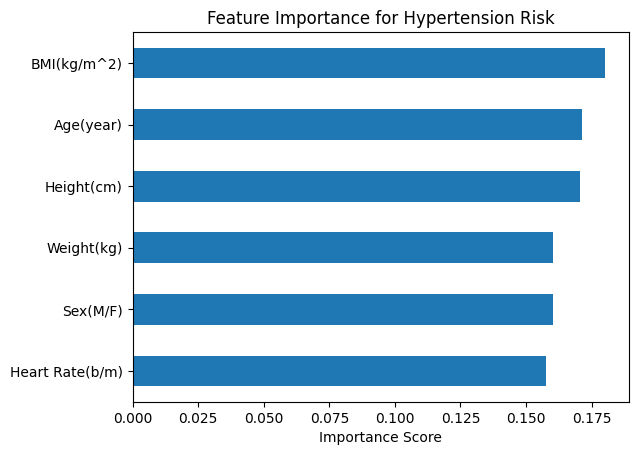

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

feat_imp = pd.Series(xgb_bin.feature_importances_, index=X_noleak.columns)
feat_imp.sort_values().plot(kind='barh', title="Feature Importance for Hypertension Risk")
plt.xlabel("Importance Score")
plt.show()


In [29]:

import joblib
joblib.dump(scaler, "diabetes_encoder.pkl")

['diabetes_encoder.pkl']

In [28]:
joblib.dump(xgb_bin, "bp_model.pkl")


['bp_model.pkl']

In [30]:
joblib.dump(X_noleak.columns.tolist(), "bp_features.pkl")


['bp_features.pkl']

In [56]:
def bp_risk_level(prob):
    """Map hypertension risk probability (0-1) to a categorical level."""
    if prob >= 0.8:
        return "HIGH"
    elif prob >= 0.5:
        return "MEDIUM"
    else:
        return "LOW"

# Example usage (after computing y_prob = model.predict_proba(... )[:, 1]):
# bp_risk_labels = [bp_risk_level(p) for p in y_prob]

In [59]:
import joblib
import pandas as pd

# 1) Load saved BP artifacts
bp_model = joblib.load("bp_model.pkl")
bp_scaler = joblib.load("diabetes_encoder.pkl")   # scaler saved in this notebook
bp_features = joblib.load("bp_features.pkl")

print("BP model expects features (in order):")
print(bp_features)

# 2) Define ONE new patient using EXACTLY these feature names
#    Here we use example numeric values; change them if you like.
new_patient = {
    "Sex(M/F)": 1,            # 1 = Male, 0 = Female
    "Age(year)": 45,
    "Height(cm)": 170,
    "Weight(kg)": 70,
    "Heart Rate(b/m)": 75,
    "BMI(kg/m^2)": 24.2,
}

# 3) Build DataFrame in correct column order
X_new = pd.DataFrame([new_patient])[bp_features]

# 4) Apply same scaling as training
X_new_scaled = bp_scaler.transform(X_new)

# 5) Predict probability and risk level
prob = bp_model.predict_proba(X_new_scaled)[:, 1][0]
level = bp_risk_level(prob)   # function we added earlier

print("BP risk probability:", prob)
print("BP risk level:", level)

BP model expects features (in order):
['Sex(M/F)', 'Age(year)', 'Height(cm)', 'Weight(kg)', 'Heart Rate(b/m)', 'BMI(kg/m^2)']
BP risk probability: 0.05669079
BP risk level: LOW


In [60]:
new_patient = {
    "Sex(M/F)": 1,          # 1 = Male, 0 = Female
    "Age(year)": 68,        # older age
    "Height(cm)": 165,
    "Weight(kg)": 95,       # higher weight
    "Heart Rate(b/m)": 95,  # elevated heart rate
    "BMI(kg/m^2)": 34.9,    # obese range
}
# 3) Build DataFrame in correct column order
X_new = pd.DataFrame([new_patient])[bp_features]

# 4) Apply same scaling as training
X_new_scaled = bp_scaler.transform(X_new)

# 5) Predict probability and risk level
prob = bp_model.predict_proba(X_new_scaled)[:, 1][0]
level = bp_risk_level(prob)   # function we added earlier

print("BP risk probability:", prob)
print("BP risk level:", level)

BP risk probability: 0.8348779
BP risk level: HIGH


In [ ]:
import joblib
import pandas as pd

# Load saved BP model artifacts
bp_model = joblib.load("bp_model.pkl")
bp_scaler = joblib.load("diabetes_encoder.pkl")  # scaler saved earlier in this notebook
bp_features = joblib.load("bp_features.pkl")

print("BP model expects features (in order):")
print(bp_features)

# To predict for a new patient, create a dict with ALL these keys.
# Example (fill with real values):

# new_patient = {
#     "age": 45,
#     "BMI": 27.5,
#     ...  # one entry for each feature in bp_features
# }

# Then run:

# X_new = pd.DataFrame([new_patient])[bp_features]
# X_new_scaled = bp_scaler.transform(X_new)
# prob = bp_model.predict_proba(X_new_scaled)[:, 1][0]
# level = bp_risk_level(prob)
# print("BP risk probability:", prob)
# print("BP risk level:", level)